# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды

Выполнили студенты гр. 2384 Федоров Михаил и Муравин Егор. Вариант №30

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.

## Постановка задачи

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

## Основные теоретические положения

+ **Генеральная совокупность** - Это совокупность всех объектов (единиц), признаки которых должны быть измерены или оценены и определяются целями исследования.

+ **Выборочная совокупность** - Сравнительно небольшое число объектов, изучение которых может дать определенный объём информации о генеральной совокупности.

+ **Ранжированный ряд** - Последовательность значений признаков, упорядоченная по возрастанию или убыванию.

+ **Варианта** - Отдельные значения признака, которые он принимает в вариационном ряду.

+ **Частота** - Число, показывающее, сколько раз повторяется варианта.

+ **Вариационный ряд** - Ряд, в котором сопоставлены (по степени возрастания или убывания) варианты и соответствующие им частоты.

+ **Интервальный ряд** - Это упорядоченная совокупность интервалов варьирования значений случайной величины с соответствующими частотами или относительными частотами попаданий в каждый из них значений величины.

    - Формула Стерджесса:
        $ k = 1 + 3,322 \lg N $

    - Ширина интервала:
        $ h = \frac{x_{max} - x_{min}}{k}$

+ **Абсолютная частота** — Число, показывающее, сколько раз конкретное значение встречается в интервале.

+ **Относительная частота** — Доля, которую составляет абсолютная частота данного значения от общего числа.

+ **Накопленная абсолютная частота** — Результат суммирования абсолютных частот всех значений, не превышающих данное.

+ **Накопленная относительная частота** — Результат суммирования относительных частот всех значений, не превышающих данное.

#### Термины визуализации

+ **Полигон** — Ломаная линия, соединяющая точки, соответствующие серединным значениям интервалов.

+ **Гистограмма** — Изображение, состоящее из прямоугольников, высота которых пропорциональна частоте попадания в эти интервалы.

+ **Эмпирическая функция распределения** — Ступенчатая функция, значение которой для каждого действительного значения *x* равно относительной частоте наблюдений, принявших значение меньшее, чем *x*.

## Выполнение работы


### 1. Выбрать программное обеспечение или язык программирования для выполнения практических работ и обосновать его выбор.

В качестве языка программирования был выбран Python - один из самых популярных и гибких языков программирования с большим обилием готовых библиотек, которые позволяют облегчить работу в совершенно разных сферах деятельности, в том числе при обработке и визуализации данных. 

### 2. Выбрать двумерную генеральную совокупность, предварительно согласовав её с преподавателем. Указать, откуда была взята генеральная совокупность и предоставить ссылку

Генеральная выборка была сформирована из предоставленного преподавателем датасета с сайта se.moevm.info, раздела "учебные материалы", по [ссылке](https://se.moevm.info/lib/exe/fetch.php/courses:statistical_methods_of_experimental_data_handling:sample.zip).

### 3. Из генеральной совокупности сформировать выборку заданного объёма в соответствии с полученным от преподавателя номером. Указать, каким образом была сформирована выборка.

Из генеральной совокупности была сформирована выборка объемом 118 наблюдений с помощью встроенных средств библиотеки `pandas`, методом `sample`. Для детерминированности выбора использовано **случайное** семя (`random_state=1`).

In [59]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import math


In [60]:
import pandas as pd
df = pd.read_csv("data.csv", sep=",")
df.rename(columns={"nu": "relative_weight", "E": "simplicity"}, inplace=True)
df = df.sample(n=118, random_state=1)
df

,relative_weight,simplicity
94,458,133.5
54,440,126.7
59,437,129.2
115,429,112.9
74,503,149.9
...,...,...
9,566,175.7
72,436,114.3
12,500,155.5
107,471,119.7


In [61]:
print("Статистика relative_weight")
df["relative_weight"].describe()

Статистика relative_weight


count    118.000000
mean     456.135593
std       54.446699
min      320.000000
25%      422.000000
50%      447.000000
75%      494.500000
max      623.000000
Name: relative_weight, dtype: float64

In [62]:
print("Статистика simplicity")
df["simplicity"].describe()

Статистика simplicity


count    118.000000
mean     129.742373
std       22.896017
min       71.100000
25%      115.250000
50%      128.500000
75%      144.475000
max      195.700000
Name: simplicity, dtype: float64

### 4. Последовательно преобразовать выборку в ранжированный, вариационный и интервальный ряды. Интервальный ряд представить в виде табл. 1. Результаты содержательно проинтерпретировать.

In [63]:
# Ранжированный ряд
def build_ranged_row(data: pd.Series):
    return data.sort_values()

# Вариационный ряд
def build_var_row(data: pd.Series):
    return data.value_counts().sort_values()

# Интервальный ряд
def build_intervals_row(data: pd.Series):
    x_min = data.min()
    x_max = data.max()

    k = math.ceil(1 + 3.322 * math.log10(len(data)))
    print(f"Количество интервалов: {k}")
    print(f"x_min = {x_min}, x_max = {x_max}")

    h = (x_max - x_min) / k
    h_round = round(h, 2)
    print(f"Длина шага: {h_round}")

    boundaries = [x_min]
    for _ in range(k):
        boundaries.append(round(boundaries[-1] + h, 2))
    
    if boundaries[-1] < x_max:
        boundaries.append(round(boundaries[-1] + h, 2))
    
    print(f"Фактически интервалов: {len(boundaries) - 1}")

    counts, edges = np.histogram(data, bins=boundaries)
    midpoints = (edges[:-1] + edges[1:]) / 2 
    rel_freqs = counts / len(data)
    cum_counts = np.cumsum(counts)
    cum_rel_freqs = np.cumsum(rel_freqs)

    table = pd.DataFrame({
        "Интервал": [f"[{edges[i]:.2f}, {edges[i+1]:.2f})" for i in range(len(counts))],
        "Середина": midpoints,
        "Абс. частота": counts,
        "Отн. частота": rel_freqs,
        "Накопл. абс. частота": cum_counts,
        "Накопл. отн. частота": cum_rel_freqs
    })

    sum_row = pd.DataFrame({
        "Интервал": ["-"],
        "Середина": ["-"],
        "Абс. частота": [counts.sum()],
        "Отн. частота": [round(rel_freqs.sum(), 4)],
        "Накопл. абс. частота": ["-"],
        "Накопл. отн. частота": ["-"]
    })
    
    table_full = pd.concat([table, sum_row], ignore_index=True)

    return midpoints, counts, boundaries, cum_counts, h, rel_freqs, cum_rel_freqs, table_full


# Построение графиков
def build_plots(midpoints, freq_data, boundaries, cum_freq_data, h, freq_type="absolute"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Полигон 
    ax = axes[0]
    ax.plot(midpoints, freq_data, "bo-", linewidth=2, markersize=6)
    ax.grid(True, alpha=0.3)
    for xi, mi in zip(midpoints, freq_data):
        if freq_type == "absolute":
            ax.annotate(f"{mi}", (xi, mi), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
        else:
            ax.annotate(f"{mi:.3f}", (xi, mi), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
    
    # Гистограмма
    ax = axes[1]
    color = "steelblue" if freq_type == "absolute" else "forestgreen"
    ax.bar(midpoints, freq_data, width=h * 0.9, edgecolor="black", color=color, alpha=0.7)
    ax.grid(True, alpha=0.3, axis="y")
    for xi, mi in zip(midpoints, freq_data):
        if freq_type == "absolute":
            ax.text(xi, mi + 0.3, str(mi), ha="center", fontsize=8)
        else:
            ax.text(xi, mi + 0.005, f"{mi:.3f}", ha="center", fontsize=8)
    
    # Эмпирическая функция
    ax = axes[2]
    color = "darkblue" if freq_type == "absolute" else "darkgreen"
    ax.step(boundaries, [0] + list(cum_freq_data), where="post", linewidth=2, color=color)
    ax.plot(boundaries[1:], cum_freq_data, "ro", markersize=4)
    ax.grid(True, alpha=0.3)
    if freq_type == "relative":
        ax.set_ylim(-0.05, 1.05)
    
    return fig, axes


# Установка текста и отрисовка
def set_text_and_draw(var_name, units, fig, axes, freq_type="absolute"):
    if freq_type == "absolute":
        fig.suptitle(f"{var_name} ({units}) - Абсолютные частоты", fontsize=14, fontweight="bold")
        
        # Полигон 
        ax = axes[0]
        ax.set_xlabel(f"{var_name} ({units})")
        ax.set_ylabel("Абсолютная частота")
        ax.set_title("Полигон частот")
        
        # Гистограмма
        ax = axes[1]
        ax.set_xlabel(f"{var_name} ({units})")
        ax.set_ylabel("Абсолютная частота")
        ax.set_title("Гистограмма")
        
        # Эмпирическая функция
        ax = axes[2]
        ax.set_xlabel(f"{var_name} ({units})")
        ax.set_ylabel("Накопленная абсолютная частота")
        ax.set_title("Эмпирическая функция (абс.)")
    else:
        fig.suptitle(f"{var_name} ({units}) - Относительные частоты", fontsize=14, fontweight="bold")
        
        # Полигон 
        ax = axes[0]
        ax.set_xlabel(f"{var_name} ({units})")
        ax.set_ylabel("Относительная частота")
        ax.set_title("Полигон частот")
        
        # Гистограмма
        ax = axes[1]
        ax.set_xlabel(f"{var_name} ({units})")
        ax.set_ylabel("Относительная частота")
        ax.set_title("Гистограмма")
        
        # Эмпирическая функция
        ax = axes[2]
        ax.set_xlabel(f"{var_name} ({units})")
        ax.set_ylabel("Накопленная относительная частота")
        ax.set_title("Эмпирическая функция распределения")
    
    plt.tight_layout()
    plt.show()


In [64]:
# Признак relative_weight
relative_weight = df["relative_weight"]

rr = build_ranged_row(relative_weight)
print("Ранжированный ряд: relative_weight")
print(rr)
print()

vr = build_var_row(relative_weight)
print("Вариационный ряд: relative_weight")
print(vr)
print()


print("Интервальный ряд: relative_weight")
midpoints, counts, boundaries, cum_counts, h, rel_freqs, cum_rel_freqs, table = build_intervals_row(relative_weight)

table

Ранжированный ряд: relative_weight
18     320
23     330
13     359
109    362
8      362
      ... 
9      566
43     573
80     576
25     593
116    623
Name: relative_weight, Length: 118, dtype: int64

Вариационный ряд: relative_weight
relative_weight
576    1
372    1
472    1
536    1
497    1
      ..
422    3
518    3
446    3
480    3
438    3
Name: count, Length: 88, dtype: int64

Интервальный ряд: relative_weight
Количество интервалов: 8
x_min = 320, x_max = 623
Длина шага: 37.88
Фактически интервалов: 8


,Интервал,Середина,Абс. частота,Отн. частота,Накопл. абс. частота,Накопл. отн. частота
0,"[320.00, 357.88)",338.94,2,0.016949,2,0.016949
1,"[357.88, 395.76)",376.82,10,0.084746,12,0.101695
2,"[395.76, 433.64)",414.7,27,0.228814,39,0.330508
3,"[433.64, 471.52)",452.58,38,0.322034,77,0.652542
4,"[471.52, 509.40)",490.46,20,0.169492,97,0.822034
5,"[509.40, 547.28)",528.34,15,0.127119,112,0.949153
6,"[547.28, 585.16)",566.22,4,0.033898,116,0.983051
7,"[585.16, 623.04)",604.1,2,0.016949,118,1.0
8,-,-,118,1.000000,-,-


Из ранжированного ряда можно увидеть максимальное и минимальное значение, находящиеся на концах списка. Минимальное значение - 320, максимальное - 623.

По вариационному ряду можно выявить самые частовстречаемые значения в наблюдениях. В текущем случае элементы встречаются максимум 3 раза.

Из интервального ряда можно увидеть распределение элементов по рассчитанным интервалам. Самый наполненный ряд - номер 3 [433.64; 471.52), он включает в себя 38 наблюдений, что составляет 32% от всей выборки. Остальные интервалы имеют меньшее количество наблюдений. На втором месте по наполненности находится интервал номер 2, включающийся в себя 27 наблюдений и отличается от максимального на 11 пунктов. Наименьшее содержание у крайних интервалов, которые включают в себя по 2 наблюдения, что составляет менее 3% всей выборки. 

In [65]:
# Признак simplicity
simplicity = df["simplicity"]

rr = build_ranged_row(simplicity)
print("Ранжированный ряд: simplicity")
print(rr)
print()

vr = build_var_row(simplicity)
print("Вариационный ряд: simplicity")
print(vr)
print()


print("Интервальный ряд: simplicity")
s_midpoints, s_counts, s_boundaries, s_cum_counts, s_h, s_rel_freqs, s_cum_rel_freqs, s_table = build_intervals_row(simplicity)

s_table

Ранжированный ряд: simplicity
23      71.1
13      71.9
18      72.6
97      81.7
7       90.1
       ...  
17     174.6
9      175.7
98     181.0
25     187.4
116    195.7
Name: simplicity, Length: 118, dtype: float64

Вариационный ряд: simplicity
simplicity
133.5    1
126.7    1
166.4    1
154.7    1
105.7    1
        ..
155.8    2
108.6    2
144.5    2
134.1    2
130.3    2
Name: count, Length: 112, dtype: int64

Интервальный ряд: simplicity
Количество интервалов: 8
x_min = 71.1, x_max = 195.7
Длина шага: 15.58
Фактически интервалов: 8


,Интервал,Середина,Абс. частота,Отн. частота,Накопл. абс. частота,Накопл. отн. частота
0,"[71.10, 86.68)",78.89,4,0.033898,4,0.033898
1,"[86.68, 102.26)",94.47,6,0.050847,10,0.084746
2,"[102.26, 117.84)",110.05,24,0.203390,34,0.288136
3,"[117.84, 133.42)",125.63,38,0.322034,72,0.610169
4,"[133.42, 148.99)",141.205,24,0.203390,96,0.813559
5,"[148.99, 164.56)",156.775,14,0.118644,110,0.932203
6,"[164.56, 180.14)",172.35,5,0.042373,115,0.974576
7,"[180.14, 195.71)",187.925,3,0.025424,118,1.0
8,-,-,118,1.000000,-,-


Из ранжированного ряда можно увидеть максимальное и минимальное значение, находящиеся на концах списка. Минимальное значение - 71.81, максимальное - 195.7.

По вариационному ряду можно выявить самые частовстречаемые значения в наблюдениях. В текущем случае элементы встречаются максимум 2 раза.

Из интервального ряда можно увидеть распределение элементов по рассчитанным интервалам. Самый наполненный ряд - номер 3 [117.84; 133.42), он включает в себя 38 наблюдений, что составляет 32% от всей выборки. Остальные интервалы имеют меньшее количество наблюдений. На втором месте по наполненности находятся интервалы номер 2 и 3, включающие в себя по 24 наблюдения и отличается от максимального на 14 пунктов. Наименьшее содержание у 7 интервала, который включает в себя 3 наблюдения. 

### 5. Для абсолютных частот построить и отобразить графически полигон, гистограмму и эмпирическую функцию. Сделать выводы

### 6. Выполнить п. 5 для относительных частот. Сравнить результаты и сделать выводы.

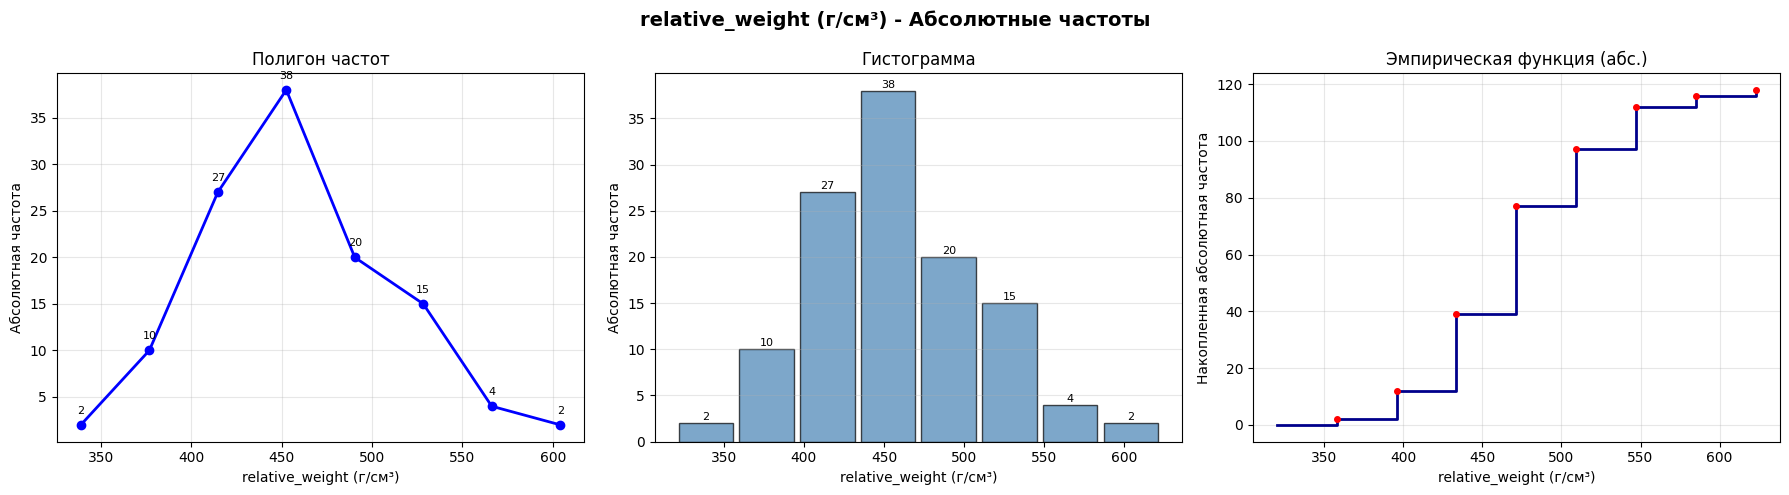

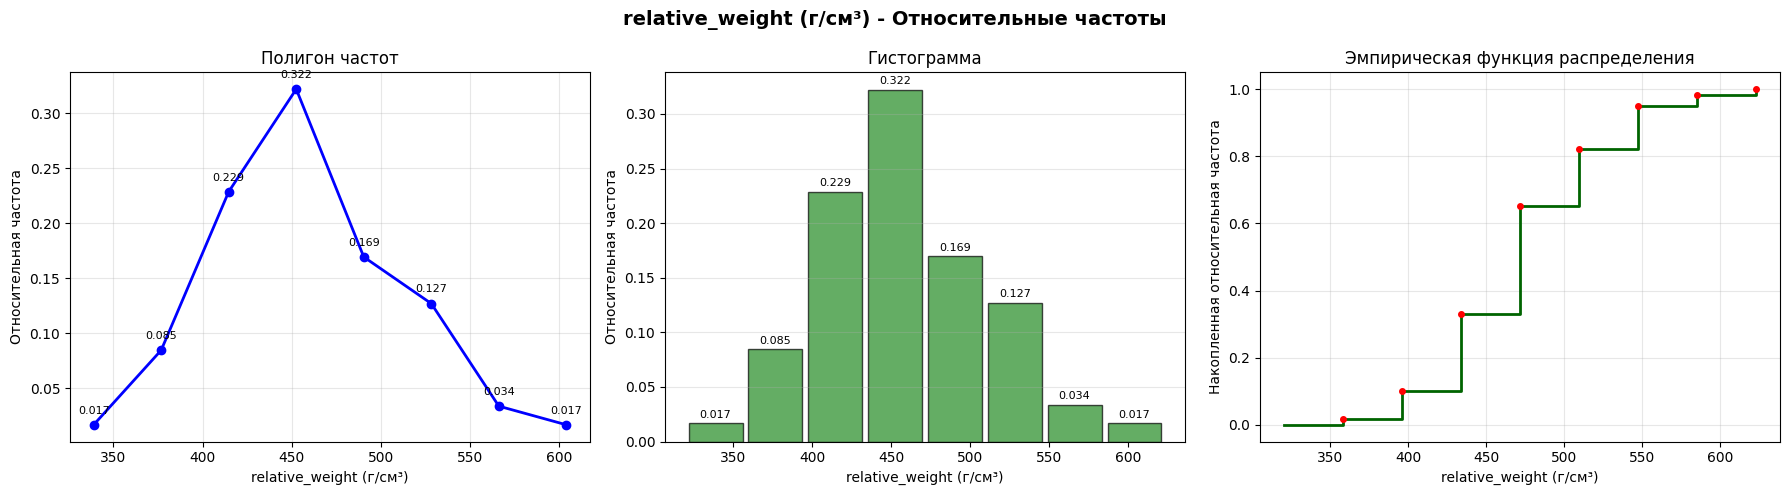

In [66]:
fig, axes = build_plots(midpoints, counts, boundaries, cum_counts, h, freq_type="absolute")
set_text_and_draw("relative_weight", "г/см³", fig, axes, freq_type="absolute")

fig, axes = build_plots(midpoints, rel_freqs, boundaries, cum_rel_freqs, h, freq_type="relative")
set_text_and_draw("relative_weight", "г/см³", fig, axes, freq_type="relative")

Графики абсолютных и относительных идентичны по форме и отличаются лишь масштабом данных. По гистограмме и полигону частиц можно увидеть асимметрию данных. Пик наблюдений находится в районе значения 450, что является 3 интервалом (отсчет с нуля). Наибольшая частота - 38 наблюдений. Слевой стороны наблюдается резкий подьем, спарва - более плавный спад. По эмпирической функции распределения наблюдается резкий скачок с центрального значения - спад. По бокам эмпирической функции можно увидеть "меленькие" ступеньки, указывающие на незначительные изменения количества наблюдений в интервале.

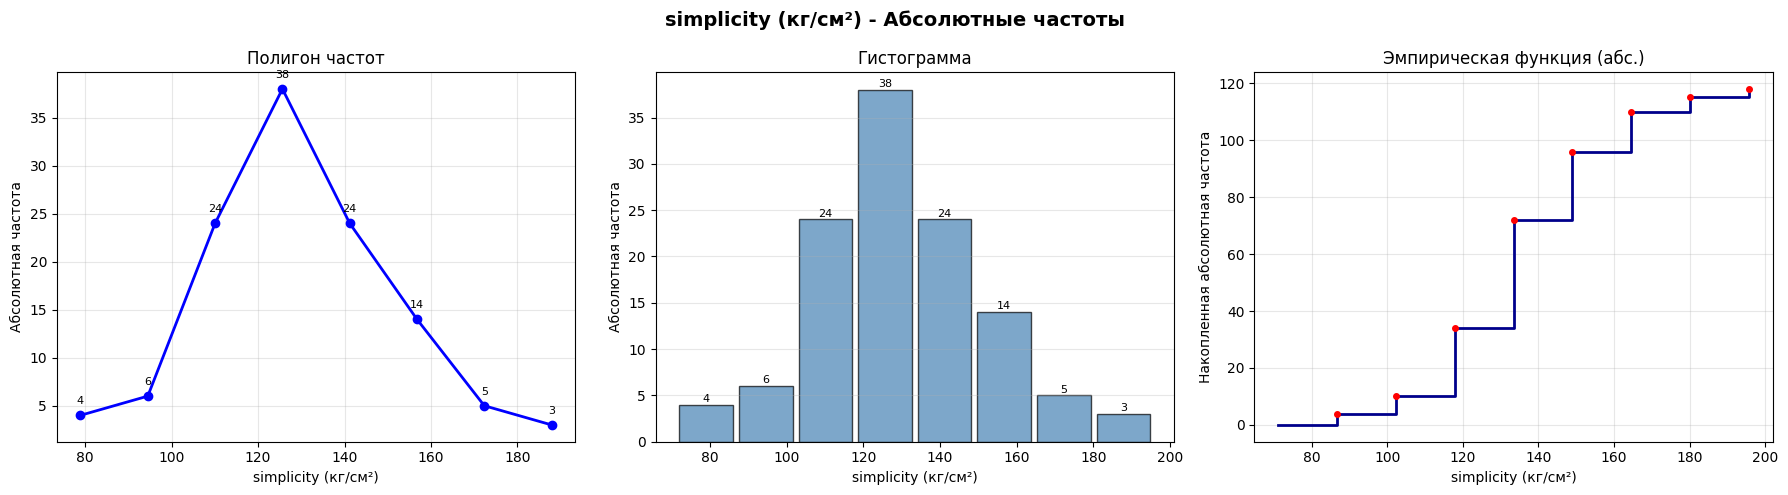

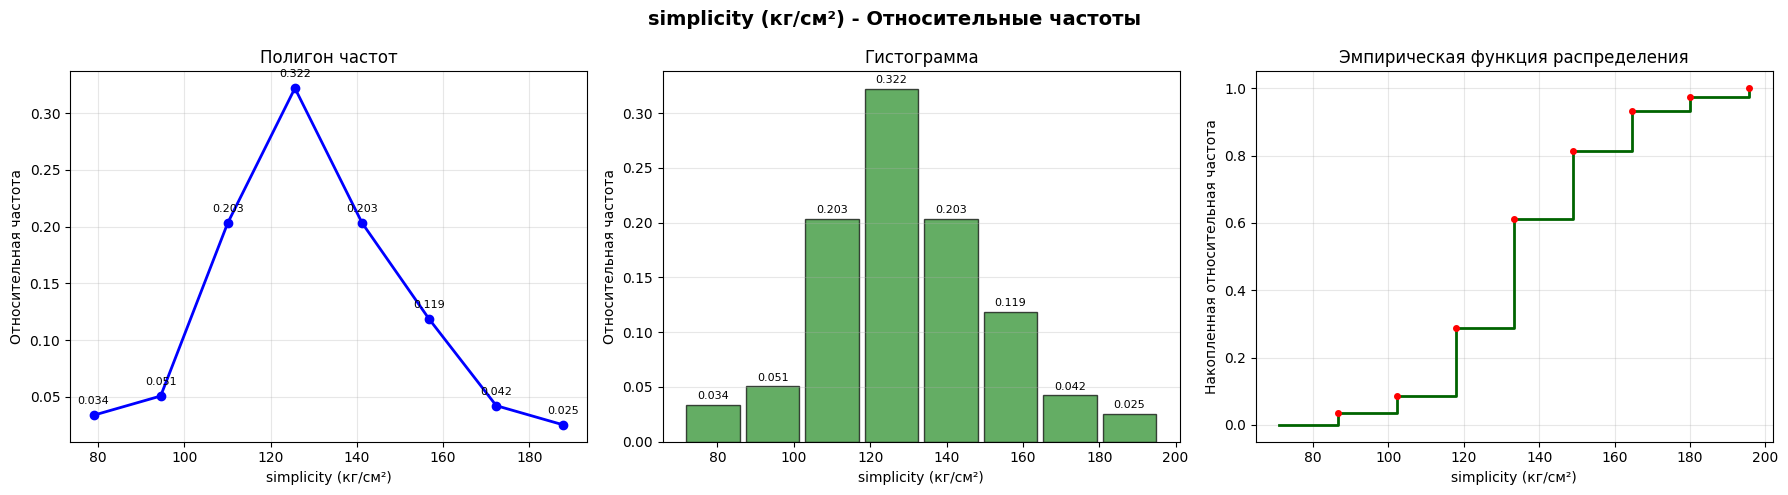

In [67]:
fig, axes = build_plots(s_midpoints, s_counts, s_boundaries, s_cum_counts, s_h, freq_type="absolute")
set_text_and_draw("simplicity", "кг/см²", fig, axes, freq_type="absolute")

fig, axes = build_plots(s_midpoints, s_rel_freqs, s_boundaries, s_cum_rel_freqs, s_h, freq_type="relative")
set_text_and_draw("simplicity", "кг/см²", fig, axes, freq_type="relative")


В данных графиках можно наблюдать большую симметрию. Пик значения смещен слегка влево, относительно центрального значения между минимумом и максимумом значений. Максимальное значение абсолютной частоты - 38, принимаемое на 3 интервале. По графику эмипирической функции можно наблюдать максимальные изменения в центральной части, по бокам значения меняются не так сильно.

Оба признака показали пик абсолютных частот (38 наблюдений) на третьем интервале при общем количестве интервалов, равном 7. Однако характер распределения вокруг модального интервала различается: у признака simplicity наблюдается относительная симметрия относительно пика, в то время как для relative_weight характерен более плавный, но резкий подъем к максимальному значению и последующий пологий спад, что свидетельствует о правосторонней асимметрии распределения.

### **Выводы**
В ходе работы были изучены основы формирования и обработки выборки данных. Из генеральной совокупности была отобрана выборочная совокупность объемом 118 наблюдений, состоящая из 2 признаков. Затем производилась подготовка к статистическому анализу путем формирования ранжированного, вариационного и интервального ряда с помощью средств библиотеки `pandas`. Для формирования ранжированного ряда использовалась простая сортировка, для вариационного - группировка и подсчет данных, интервальный ряд формировался с помощью формулы Стерджесса для определения оптимального числа интервалов, после чего рассчитывался шаг интервала и выполнялось построение самих интервалов. Для обоих признаков максимальная частота составила 38 единиц, приходящаяся на третий интервал. Были построены и проанализированы графики для абсолютных и относительных частот, позволившие визуально оценить форму распределений, пики значений и равномерность распределения признаков.